In [ ]:
import numpy as np
import pandas as pd



In [1]:
def prepare_ml_data(ts, window_size=12, split_date='2014-01-01'):
    
    ts = ts.copy()
    ts['flow'] = ts['flow'].clip(lower=0)

    # Seasonal encoding
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # Log transform
    y_log = np.log1p(y)

    # Train/test split
    split_date = pd.to_datetime(split_date)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],        # original scale
        "idx_test": idx[split:]
    }

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return rmse, mae, nse

In [3]:
from sklearn.ensemble import RandomForestRegressor

def train_rf(data):
    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(data["X_train"], data["y_train"])
    return model


def predict_rf(model, data):
    y_pred_log = model.predict(data["X_test"])
    y_pred = np.expm1(y_pred_log)
    return np.maximum(y_pred, 0)


from xgboost import XGBRegressor

def train_xgb(data):
    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
    model.fit(data["X_train"], data["y_train"])
    return model


def predict_xgb(model, data):
    y_pred_log = model.predict(data["X_test"])
    y_pred = np.expm1(y_pred_log)
    return np.maximum(y_pred, 0)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def train_nn(data):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(data["X_train"].shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(data["X_train"], data["y_train"], epochs=4000, verbose=0)

    return model


def predict_nn(model, data):
    y_pred_log = model.predict(data["X_test"]).flatten()
    y_pred = np.expm1(y_pred_log)
    return np.maximum(y_pred, 0)

2026-04-08 10:13:52.503541: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
import matplotlib.pyplot as plt

def evaluate_models(ts, label):

    data = prepare_ml_data(ts)

    results = {}

    # -----------------------------
    # Train models
    # -----------------------------
    rf = train_rf(data)
    xgb = train_xgb(data)
    #nn = train_nn(data)

    # -----------------------------
    # Predict
    # -----------------------------
    preds = {
        "RF": predict_rf(rf, data),
        "XGB": predict_xgb(xgb, data),
        #"NN": predict_nn(nn, data)
    }

    y_true = data["y_test"]
    idx = data["idx_test"]

    # -----------------------------
    # Metrics
    # -----------------------------
    print("\nMODEL COMPARISON")
    print("Model      RMSE     MAE     NSE")
    print("-----------------------------------")

    for name, pred in preds.items():
        min_len = min(len(y_true), len(pred))
        yt = y_true[:min_len]
        yp = pred[:min_len]

        rmse, mae, nse = compute_metrics(yt, yp)
        results[name] = (rmse, mae, nse)

        print(f"{name:5s}   {rmse:.2f}   {mae:.2f}   {nse:.4f}")

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_true, label='Actual')

    for name, pred in preds.items():
        plt.plot(idx[:len(pred)], pred, label=name)

    plt.legend()
    plt.title(f"Model Comparison (2014–2025): {label}")
    plt.grid(True)
    plt.show()

    return results
    

In [5]:
## RUN the models:

import pandas as pd

# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

def prepare_time_series(df, value_name='flow'):
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]

    # Convert to numeric and fill missing
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')

    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.dropna(subset=['date'])
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    # Ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)
    
    return ts

ts_qmin = prepare_time_series(q_min)





MODEL COMPARISON
Model      RMSE     MAE     NSE
-----------------------------------
RF      26.88   19.43   0.4061
XGB     27.71   20.20   0.3687


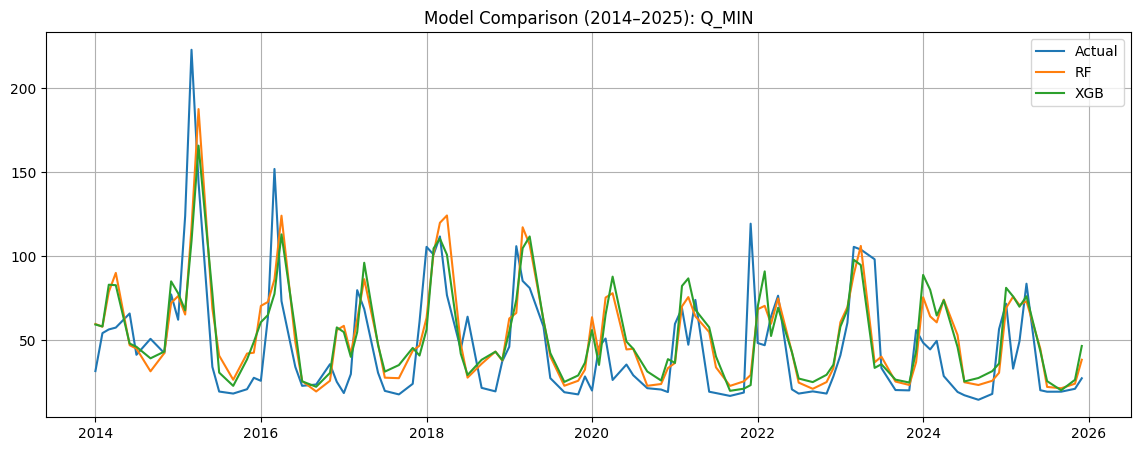

In [6]:
# Compare models on Q_MIN
results_qmin = evaluate_models(ts_qmin, "Q_MIN")

In [7]:
#If you want to push this to publishable level, I can extend this with:
#
#✅ statistical significance test (Diebold–Mariano)
#✅ hyperparameter tuning (Optuna)
#✅ hybrid model (SARIMA + XGB residuals) → usually best NSE
#✅ cross-validation for time series (rolling window)



In [8]:
################################ TUNE THE MODELS #########################################

import numpy as np

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return 0
    return 1 - np.sum((y_true - y_pred)**2) / denom

def tune_rf(X_train, y_train):
    param_dist = {
        'n_estimators': [200, 500, 1000],
        'max_depth': [3, 5, 8, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 0.8]
    }
    
    # Custom NSE scorer
    from sklearn.metrics import make_scorer
    nse_scorer = make_scorer(nse, greater_is_better=True)
    
    tscv = TimeSeriesSplit(n_splits=5)
    rf = RandomForestRegressor(random_state=42)
    
    search = RandomizedSearchCV(
        rf, param_distributions=param_dist,
        n_iter=20, scoring=nse_scorer,
        cv=tscv, verbose=1, n_jobs=-1, random_state=42
    )
    search.fit(X_train, y_train)
    print("Best RF params (max NSE):", search.best_params_)
    print("Best NSE:", search.best_score_)
    return search.best_estimator_

#### tune XGB

from xgboost import XGBRegressor

def nse_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    return 'NSE', nse(y_true, y_pred)

def tune_xgb(X_train, y_train):
    # You can tune these parameters
    param_grid = {
        'n_estimators': [500, 800, 1000],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }
    best_score = -np.inf
    best_model = None
    params_best = None
    
    import itertools
    for n_est, max_d, lr, sub, col in itertools.product(
        param_grid['n_estimators'], param_grid['max_depth'],
        param_grid['learning_rate'], param_grid['subsample'],
        param_grid['colsample_bytree']
    ):
        model = XGBRegressor(
            n_estimators=n_est, max_depth=max_d,
            learning_rate=lr, subsample=sub,
            colsample_bytree=col, objective='reg:squarederror',
            random_state=42, n_jobs=-1
        )
        model.fit(X_train, y_train, eval_metric=nse_eval, verbose=False)
        y_pred = model.predict(X_train)
        score = nse(y_train, y_pred)
        if score > best_score:
            best_score = score
            best_model = model
            params_best =(n_est, max_d, lr, sub, col)
    print("Best XGB NSE on train:", best_score)
    print(params_best)
    
    return best_model


def tune_nn(X_train, y_train, window_size):
    best_nse_score = -np.inf
    best_model = None
    
    for hidden1 in [32, 64]:
        for hidden2 in [16, 32]:
            model = Sequential([
                Dense(hidden1, activation='relu', input_shape=(window_size,)),
                Dense(hidden2, activation='relu'),
                Dense(1, activation='relu')  # non-negative output
            ])
            model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
            model.fit(X_train, y_train, epochs=200, verbose=0)
            y_pred = model.predict(X_train).flatten()
            score = nse(y_train, y_pred)
            if score > best_nse_score:
                best_nse_score = score
                best_model = model
    print("Best NN NSE on train:", best_nse_score)
    return best_model


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer
import numpy as np


# Prepare data
data = prepare_ml_data(ts_qmin, window_size=12)

# Random Forest 
#rf_model = tune_rf(data["X_train"], data["y_train"])
#y_pred_rf = predict_rf(rf_model, data)
#compute_metrics(data["y_test"], y_pred_rf)
#best: Best RF params (max NSE): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 8}

# XGBoost
xgb_model = tune_xgb(data["X_train"], data["y_train"])
y_pred_xgb = predict_xgb(xgb_model, data)
compute_metrics(data["y_test"], y_pred_xgb)
#(800, 7, 0.1, 0.7, 1.0)


/home/marko/.local/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


Best XGB NSE on train: 0.9982244608911631
(800, 7, 0.1, 0.7, 1.0)


(28.935629628309375, 20.95705147566618, 0.31149723966605936)


Q_MIN - RF (Tuned) Performance
RMSE: 26.56
MAE : 19.31
NSE : 0.4201


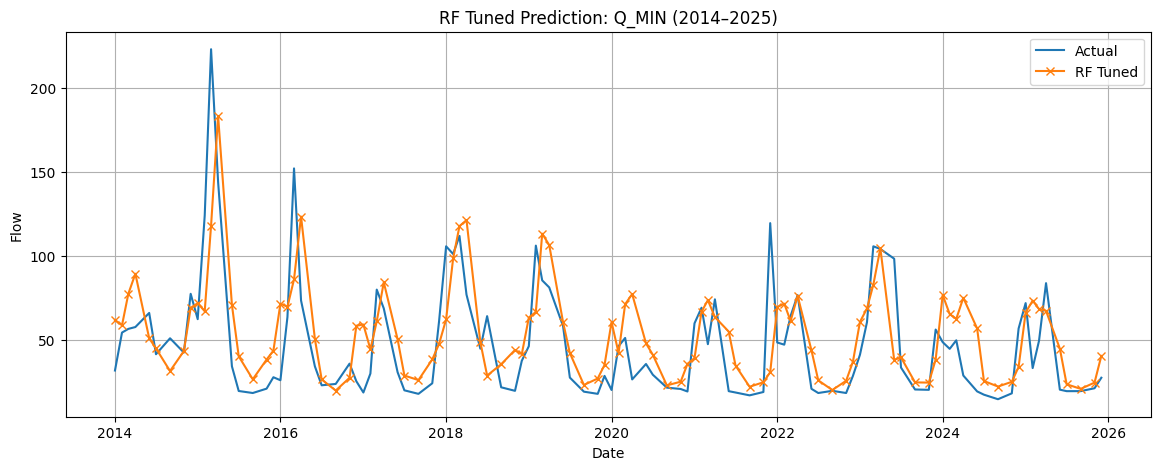

In [10]:
############################################### TEST THE TUNED MODELS #######################################################

config = {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 8}

from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

def test_rf_with_config(ts, label, config, window_size=12, start_date='2014-01-01'):
    
    # -----------------------------
    # 1. Prepare data (same pipeline)
    # -----------------------------
    data = prepare_ml_data(ts, window_size=window_size, split_date=start_date)

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # -----------------------------
    # 2. Build RF with best params
    # -----------------------------
    model = RandomForestRegressor(
        n_estimators=config['n_estimators'],
        min_samples_split=config['min_samples_split'],
        min_samples_leaf=config['min_samples_leaf'],
        max_features=config['max_features'],
        max_depth=config['max_depth'],
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # 3. Predict (log → original)
    # -----------------------------
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # -----------------------------
    # 4. Enforce non-negative
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 5. Align lengths
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # -----------------------------
    # 6. Metrics
    # -----------------------------
    rmse, mae, nse_val = compute_metrics(y_test, y_pred)

    print("\n==============================")
    print(f"{label} - RF (Tuned) Performance")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # -----------------------------
    # 7. Plot (2014–2025)
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_test, label='Actual')
    plt.plot(idx, y_pred, label='RF Tuned', marker='x')
    plt.title(f"RF Tuned Prediction: {label} (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred

## test the best RF model:

# Example usage
y_pred_rf = test_rf_with_config(ts_qmin, "Q_MIN", config)
    


Q_MIN - XGBoost (Tuned) Performance
RMSE: 27.85
MAE : 20.90
NSE : 0.3623


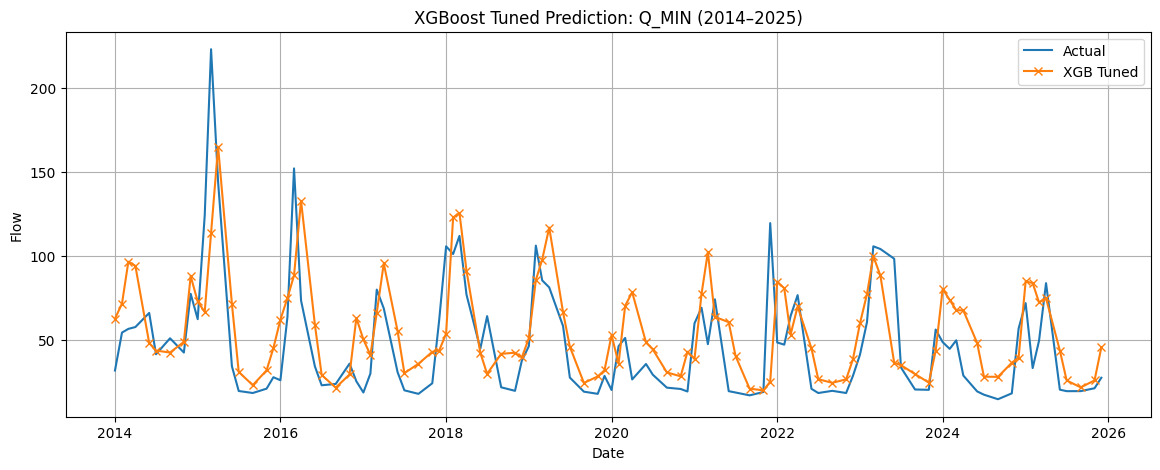

In [11]:
### test XGBoost:

config_xgb = {
    'n_estimators': 800,
    'max_depth':  7,
    'learning_rate':  0.1,
    'subsample': 0.7 ,
    'colsample_bytree':  1.0
}

from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

def test_xgb_with_config(ts, label, config, window_size=12, start_date='2014-01-01'):
    
    # -----------------------------
    # 1. Prepare data
    # -----------------------------
    data = prepare_ml_data(ts, window_size=window_size, split_date=start_date)

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # -----------------------------
    # 2. Build XGBoost model
    # -----------------------------
    model = XGBRegressor(
        n_estimators=config.get('n_estimators', 1000),
        max_depth=config.get('max_depth', 6),
        learning_rate=config.get('learning_rate', 0.05),
        subsample=config.get('subsample', 0.8),
        colsample_bytree=config.get('colsample_bytree', 0.8),
        gamma=config.get('gamma', 0),
        reg_alpha=config.get('reg_alpha', 0),
        reg_lambda=config.get('reg_lambda', 1),
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # -----------------------------
    # 3. Predict (log → original)
    # -----------------------------
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # -----------------------------
    # 4. Enforce non-negative
    # -----------------------------
    y_pred = np.maximum(y_pred, 0)

    # -----------------------------
    # 5. Align lengths
    # -----------------------------
    min_len = min(len(y_test), len(y_pred))
    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # -----------------------------
    # 6. Metrics
    # -----------------------------
    rmse, mae, nse_val = compute_metrics(y_test, y_pred)

    print("\n==============================")
    print(f"{label} - XGBoost (Tuned) Performance")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # -----------------------------
    # 7. Plot (2014–2025)
    # -----------------------------
    plt.figure(figsize=(14,5))
    plt.plot(idx, y_test, label='Actual')
    plt.plot(idx, y_pred, label='XGB Tuned', marker='x')
    plt.title(f"XGBoost Tuned Prediction: {label} (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred

config_xgb = {
    'n_estimators': 800,
    'max_depth': 5,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1
}

y_pred_xgb = test_xgb_with_config(ts_qmin, "Q_MIN", config_xgb)

